# Task 4: Classification with Logistic Regression

**Objective:** build a binary classifier using logistic regression.
**Dataset:** Breast Cancer Wisconsin (Diagnostic): `M` (malignant) = 1, `B` (benign) = 0.
**Tools:** scikit-learn, pandas, matplotlib.

Run the single cell below. In Google Colab it will ask you to upload `data.csv`.

Shape: (569, 30) | Class balance: {0: 357, 1: 212}
(455, 30) (114, 30)

=== Test set, default (threshold = 0.50) ===
Confusion matrix  TN=71 FP=1 FN=3 TP=39
Accuracy  0.9649
Precision 0.9750
Recall    0.9286
F1        0.9512
ROC-AUC   0.9960

               precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



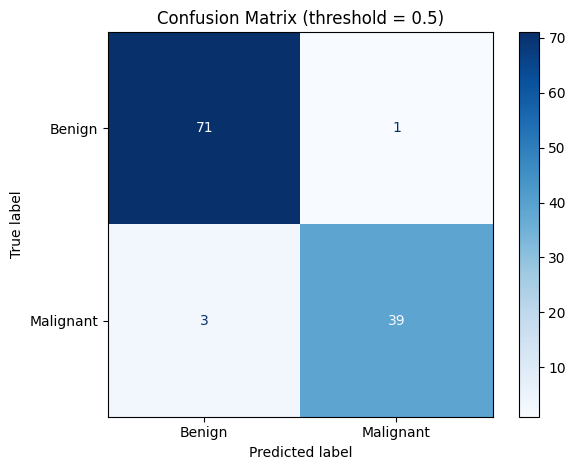

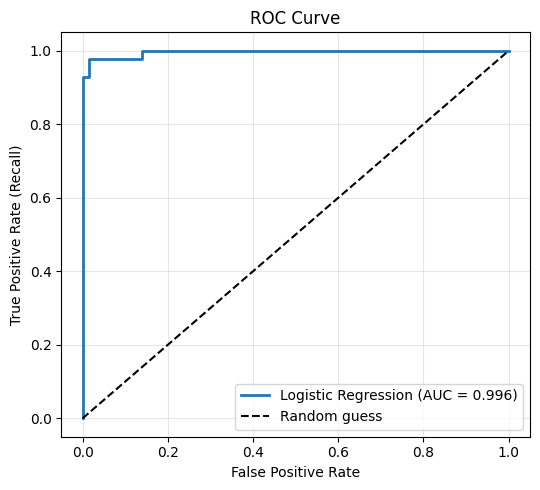

Chosen threshold (from train CV): 0.303

=== Test set, tuned (threshold = 0.30) ===
Confusion matrix  TN=71 FP=1 FN=1 TP=41
Accuracy  0.9825
Precision 0.9762
Recall    0.9762
F1        0.9762


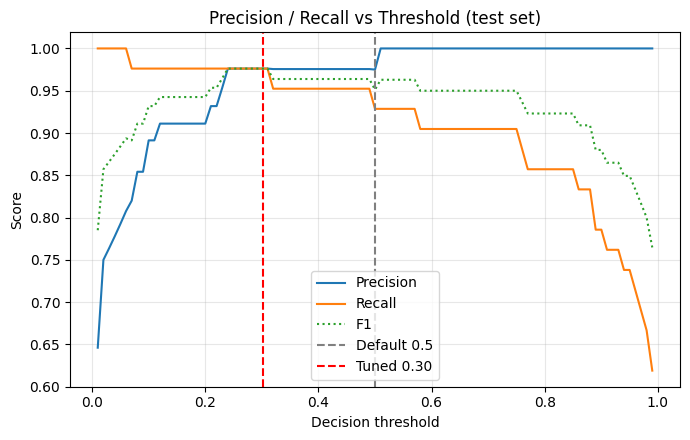

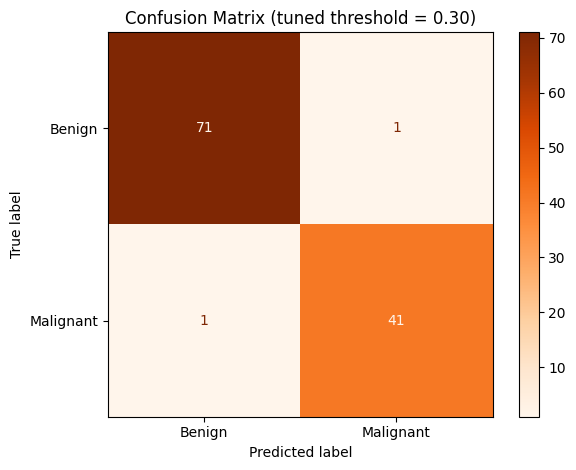

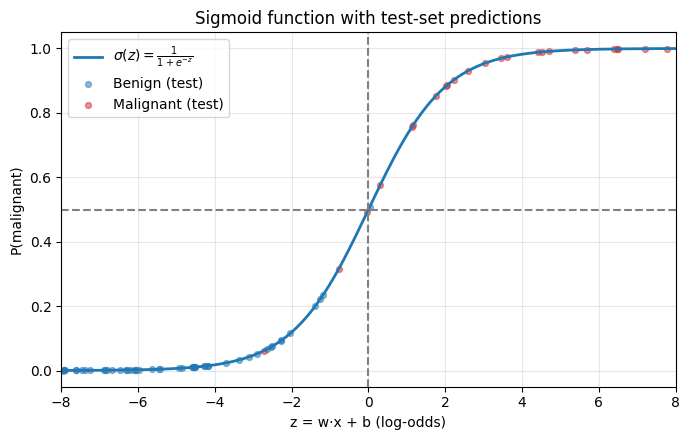

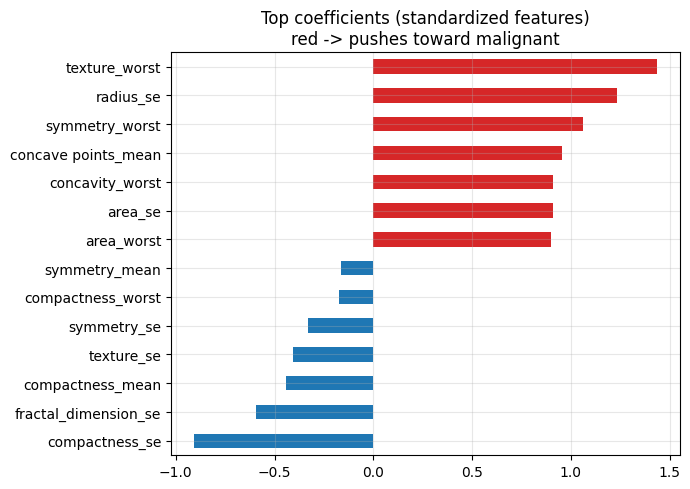

Top positive coefficients:
 concavity_worst        0.911
concave points_mean    0.953
symmetry_worst         1.061
radius_se              1.233
texture_worst          1.434


In [1]:
# ======================================================================
# 0. Imports
# ======================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, precision_score,
                             recall_score, f1_score, accuracy_score, roc_auc_score,
                             roc_curve, precision_recall_curve, classification_report)

RANDOM_STATE = 42
os.makedirs("images", exist_ok=True)   # plots are also saved here for the README

# Google Colab helper: if data.csv is not in the working folder, ask for an upload.
# (Does nothing when running locally with data.csv already present.)
if not os.path.exists("data.csv"):
    try:
        from google.colab import files
        print("Select data.csv to upload...")
        files.upload()
    except ImportError:
        raise FileNotFoundError("data.csv not found - place it next to this notebook.")

# ======================================================================
# 1. Load and clean the data
# ======================================================================
df = pd.read_csv("data.csv")
df = df.drop(columns=["id", "Unnamed: 32"])          # id = identifier, Unnamed: 32 = empty column
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})
X, y = df.drop(columns="diagnosis"), df["diagnosis"]
print("Shape:", X.shape, "| Class balance:", y.value_counts().to_dict())
df.head()

# ======================================================================
# 2. Train/test split (stratified)
# ======================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print(X_train.shape, X_test.shape)

# ======================================================================
# 3. Standardize features and fit the model
# ======================================================================
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
model.fit(X_train, y_train)
proba_test = model.predict_proba(X_test)[:, 1]

# ======================================================================
# 4. Evaluate at the default threshold (0.5)
# ======================================================================
def report(y_true, proba, thr, label):
    pred = (proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    print(f"\n=== {label} (threshold = {thr:.2f}) ===")
    print(f"Confusion matrix  TN={tn} FP={fp} FN={fn} TP={tp}")
    print(f"Accuracy  {accuracy_score(y_true, pred):.4f}")
    print(f"Precision {precision_score(y_true, pred):.4f}")
    print(f"Recall    {recall_score(y_true, pred):.4f}")
    print(f"F1        {f1_score(y_true, pred):.4f}")
    return pred

pred_default = report(y_test, proba_test, 0.5, "Test set, default")
auc = roc_auc_score(y_test, proba_test)
print(f"ROC-AUC   {auc:.4f}")
print("\n", classification_report(y_test, pred_default, target_names=["Benign", "Malignant"]))

# ======================================================================
# Confusion matrix
# ======================================================================
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_default, display_labels=["Benign", "Malignant"], cmap="Blues")
plt.title("Confusion Matrix (threshold = 0.5)")
plt.tight_layout(); plt.savefig("images/confusion_matrix.png", dpi=150); plt.show()

# ======================================================================
# ROC curve
# ======================================================================
fpr, tpr, _ = roc_curve(y_test, proba_test)
plt.figure(figsize=(5.5, 5))
plt.plot(fpr, tpr, lw=2, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve"); plt.legend(loc="lower right"); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig("images/roc_curve.png", dpi=150); plt.show()

# ======================================================================
# 5. Threshold tuning
# ======================================================================
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
oof = cross_val_predict(model, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
prec, rec, thr = precision_recall_curve(y_train, oof)
ok = rec[:-1] >= 0.97
best_thr = thr[ok][np.argmax(prec[:-1][ok])] if ok.any() else 0.5
print(f"Chosen threshold (from train CV): {best_thr:.3f}")

pred_tuned = report(y_test, proba_test, best_thr, "Test set, tuned")

# ======================================================================
# Precision / recall / F1 vs threshold
# ======================================================================
grid = np.linspace(0.01, 0.99, 99)
P = [precision_score(y_test, proba_test >= t, zero_division=0) for t in grid]
R = [recall_score(y_test, proba_test >= t) for t in grid]
F = [f1_score(y_test, proba_test >= t) for t in grid]
plt.figure(figsize=(7, 4.5))
plt.plot(grid, P, label="Precision"); plt.plot(grid, R, label="Recall"); plt.plot(grid, F, label="F1", ls=":")
plt.axvline(0.5, color="gray", ls="--", label="Default 0.5")
plt.axvline(best_thr, color="red", ls="--", label=f"Tuned {best_thr:.2f}")
plt.xlabel("Decision threshold"); plt.ylabel("Score"); plt.title("Precision / Recall vs Threshold (test set)")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout()
plt.savefig("images/threshold_tuning.png", dpi=150); plt.show()

# ======================================================================
# Confusion matrix at the tuned threshold
# ======================================================================
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_tuned, display_labels=["Benign", "Malignant"], cmap="Oranges")
plt.title(f"Confusion Matrix (tuned threshold = {best_thr:.2f})")
plt.tight_layout(); plt.savefig("images/confusion_matrix_tuned.png", dpi=150); plt.show()

# ======================================================================
# 6. The sigmoid function
# ======================================================================
z = np.linspace(-8, 8, 400)
sig = 1 / (1 + np.exp(-z))
scaled_test = model.named_steps["standardscaler"].transform(X_test)
lr = model.named_steps["logisticregression"]
z_test = lr.decision_function(scaled_test)       # z = w.x + b (the log-odds)
plt.figure(figsize=(7, 4.5))
plt.plot(z, sig, lw=2, label=r"$\sigma(z)=\frac{1}{1+e^{-z}}$")
plt.scatter(z_test[y_test == 0], 1 / (1 + np.exp(-z_test[y_test == 0])), c="tab:blue", alpha=.5, s=18, label="Benign (test)")
plt.scatter(z_test[y_test == 1], 1 / (1 + np.exp(-z_test[y_test == 1])), c="tab:red", alpha=.5, s=18, label="Malignant (test)")
plt.axhline(0.5, color="gray", ls="--"); plt.axvline(0, color="gray", ls="--")
plt.xlim(-8, 8); plt.xlabel("z = w·x + b (log-odds)"); plt.ylabel("P(malignant)")
plt.title("Sigmoid function with test-set predictions"); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig("images/sigmoid.png", dpi=150); plt.show()

# ======================================================================
# 7. Most influential features
# ======================================================================
coef = pd.Series(lr.coef_[0], index=X.columns).sort_values()
top = pd.concat([coef.head(7), coef.tail(7)])
plt.figure(figsize=(7, 5))
top.plot.barh(color=["tab:blue" if v < 0 else "tab:red" for v in top])
plt.title("Top coefficients (standardized features)\nred -> pushes toward malignant"); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig("images/coefficients.png", dpi=150); plt.show()
print("Top positive coefficients:\n", coef.tail(5).round(3).to_string())